<a href="https://colab.research.google.com/github/AnaGarcia21/fisica-computacional-2026ii/blob/main/PrtB_Taller2_FC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**B. Decaimiento radiactivo con Python**

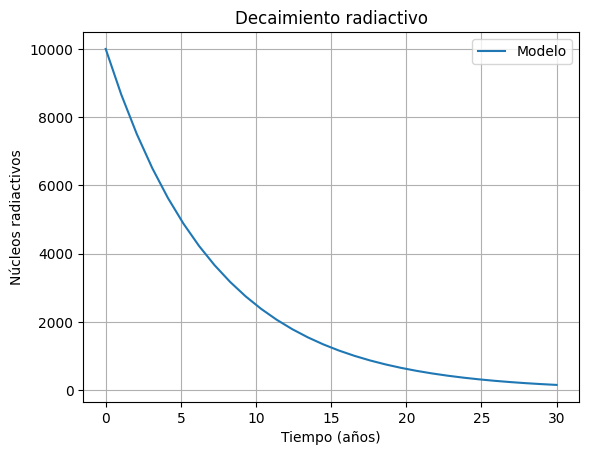

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Diccionario de datos: constantes
N_muestra = 10000                                            # Cantidad inicial de núcleos radiactivos de la muestra
vida_media = 5                                               # Vida media de la muestra

cons_decaimiento = np.log(2)/vida_media                      # Constante de decaimiento de la muestra
# --------------------------------------------


# Creando arreglo de tiempos entre 0 y 30 años
t_range = np.linspace(0, 30, 30)                             # Eligiendo 30 datos entre 0 y 30 años -> np.linspace(inicio, final, cantidad_datos)

# Creando la función: núcleos radiactivos en función del tiempo
def dec_rad(N_0, constante, tiempo):                         # Define una función para determinar la evolución de núcleos radiactivos en una muestra
  nucleos = N_0 * (np.exp(-constante*tiempo))                # Aplicando la fórmula N(t)

  return nucleos                                             # Devuelve número de núcleos presentes en ese tiempo

# Evaluando la función en el arreglo de tiempos
N_t = dec_rad(N_muestra, cons_decaimiento, t_range)          #Recorre la función creada para cada tiempo del arreglo

# Graficando
plt.title("Decaimiento radiactivo")

plt.plot(t_range, N_t, "-", label = "Modelo")

plt.xlabel("Tiempo (años)")
plt.ylabel("Núcleos radiactivos")

plt.legend()
plt.grid()
plt.show()

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; En base a la gráfica, es posible observar que:

- Al transcurrir $t_{1/2} = 5$ $años$, la cantidad de núcleos radiactivos es aproximadamente $5000$, lo cual corresponde al $50$% de la muestra original.
- Al transcurrir $2*t_{1/2} = 10$ $años$, la cantidad de núcleos radiactivos es aproximadamente $2500$, lo cual corresponde al $25$% de la muestra original.
- Al transcurrir $3*t_{1/2} = 15$ $años$, la cantidad de núcleos radiactivos se encuentra entre $1000$ y $1500$, lo cual considera el $12.5$% de la muestra original.

In [26]:
#Determinando el tiempo en el cual permanece cierto porcentaje de la muestra
t_mitad = - np.log(0.50)/cons_decaimiento                    # Tiempo  para el 50% de la muestra inicial
t_cuarto = - np.log(0.25)/cons_decaimiento                   # Tiempo  para el 25% de la muestra inicial
t_decimo = - np.log(0.10)/cons_decaimiento                   # Tiempo  para el 10% de la muestra inicial

print("Este es el tiempo en el cual permanece:")
print(f"- La mitad de la muestra inicial:     {t_mitad} años")
print(f"- Un cuarto de la muestra inicial:   {t_cuarto} años")
print(f"- Un décimo de la muestra inicial:  {t_decimo: .1f} años")

Este es el tiempo en el cual permanece:
- La mitad de la muestra inicial:     5.0 años
- Un cuarto de la muestra inicial:   10.0 años
- Un décimo de la muestra inicial:   16.6 años


***Celda de verificación (PASS/FAIL)***

In [30]:
# --- Parte B: verificando la función definida anteriormente ---
casos_b = [                                        # Lista de (t, fracción_esperada): fracción de N0 que debería quedar en cada instante.
    (0.0, 1.00),                                   # En t=0 debe quedar el 100% de la muestra.
    (5.0, 0.50),                                   # En t = t_1/2 (una vida media) debe quedar el 50%.
    (10.0, 0.25),                                  # En t = 2*t_1/2 (dos vidas medias) debe quedar el 25%.
]

for t, fraccion_esperada in casos_b:               # Recorre cada caso de prueba.
    try:                                           # Evita que un NotImplementedError detenga toda la celda de verificación.
        obtenido = dec_rad(N_muestra, cons_decaimiento, t) / 10000        # Calcula qué fracción de N0 queda en el instante t.
        ok = abs(obtenido - fraccion_esperada) < 1e-3  # Compara contra la fracción esperada con tolerancia razonable.
        estado = "PASS" if ok else "FAIL"
        print(f"{estado}  t={t:>5.1f} años   fraccion={obtenido:.3f}   esperada={fraccion_esperada:.3f}")
    except NotImplementedError as e:               # Si aún no se ha completado la función, lo informa sin detener la celda.
        print(f"FAIL  t={t:>5.1f} años   ({e})")

PASS  t=  0.0 años   fraccion=1.000   esperada=1.000
PASS  t=  5.0 años   fraccion=0.500   esperada=0.500
PASS  t= 10.0 años   fraccion=0.250   esperada=0.250
